# 04. ラプラス変換で ODE を解く — 微分方程式を代数にする

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> 初期値問題を「変換 → 代数で $Y(s)$ → 部分分数 → 逆変換」の4ステップに落とし、数値解と一致を確認。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets, discrete
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture — 4 ステップのパイプライン

ラプラス変換は、初期値問題を次の流れで「解く」のではなく「整理する」ことに変えます。

> 1. ODE を $s$ 領域へ変換(微分則で $f(0)$ が自動で入る) →
> 2. $Y(s)$ について **代数的に** 解く →
> 3. 部分分数に割る →
> 4. 逆変換で $y(t)$ へ戻す。

## 2. Problem / 3. Intuition

$$ a y'' + b y' + c y = g(t), \qquad y(0),\ y'(0)\ \text{与えられる}. $$

時間領域では同次解 + 特解 + 初期条件合わせ、と手順が多い。$s$ 領域なら微分が掛け算になり、
$$ Y(s) = \frac{G(s) + (\text{初期値の項})}{as^2 + bs + c} $$
と **一発で** 書けます。分母 $as^2+bs+c$ が系の素性(極)を決めます。

## 5. Definition / 6. Computation — 1階(まず手で)

$y' + a y = 0,\ y(0)=y_0$。変換すると $sY - y_0 + aY = 0 \Rightarrow Y=\dfrac{y_0}{s+a} \Rightarrow y=y_0e^{-at}$。

In [2]:
a, y0 = sp.symbols("a", positive=True), sp.symbols("y0")
Y = y0 / (s + a)
display(Linv(Y))           # y0 e^{-a t}

**強制つき1階**: $y' + y = 1$(ステップ入力)、$y(0)=0$。
$sY + Y = 1/s \Rightarrow Y=\dfrac{1}{s(s+1)} \Rightarrow y = 1 - e^{-t}$。

In [3]:
Y = 1 / (s * (s + 1))
display(partial_fractions(Y))     # 1/s - 1/(s+1)
display(Linv(Y))                  # 1 - e^{-t}

## 6b. 2階 — 減衰の自由振動(手計算と数値の一致)

$y'' + 3y' + 2y = 0,\ y(0)=1,\ y'(0)=0$。微分則より
$(s^2+3s+2)Y = s\,y(0) + y'(0) + 3y(0) = s + 3$。よって $Y=\dfrac{s+3}{(s+1)(s+2)}$。

Laplace solution y(t) =


max |Laplace - solve_ivp| = 5.381450840502566e-11


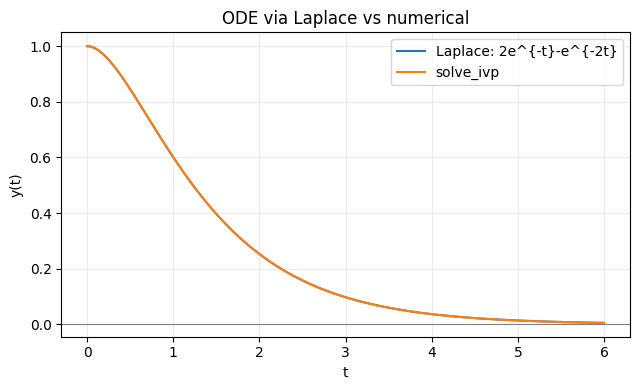

In [4]:
y0v, yp0v = 1.0, 0.0
Y = (s * y0v + yp0v + 3 * y0v) / (s**2 + 3 * s + 2)
yt = sp.simplify(Linv(Y))
print("Laplace solution y(t) ="); display(yt)            # 2 e^{-t} - e^{-2t}

# Cross-check against a direct numerical ODE solve.
from scipy.integrate import solve_ivp
tt = np.linspace(0, 6, 300)
sol = solve_ivp(lambda tau, yv: [yv[1], -3 * yv[1] - 2 * yv[0]],
                (0, 6), [1.0, 0.0], t_eval=tt, rtol=1e-9, atol=1e-12)
yfun = transforms.as_function(yt)
print("max |Laplace - solve_ivp| =", np.max(np.abs(yfun(tt) - sol.y[0])))

plotting.plot_time_responses(tt, [yfun(tt), sol.y[0]],
                             labels=["Laplace: 2e^{-t}-e^{-2t}", "solve_ivp"],
                             title="ODE via Laplace vs numerical")
plt.tight_layout()

## 7. Invariant / Structure — 強制振動と減衰の3様相

質量-バネ-ダンパ $y'' + 2\zeta\omega_n y' + \omega_n^2 y = \omega_n^2 u(t)$(ステップ強制)の応答は、
減衰比 $\zeta$ で姿が変わります。極 $s=-\zeta\omega_n\pm\omega_n\sqrt{\zeta^2-1}$ の素性そのものです。

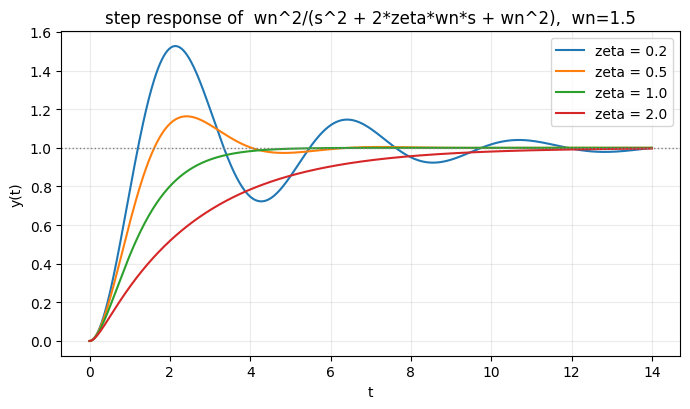

In [5]:
tt = np.linspace(0, 14, 600)
fig, ax = plt.subplots(figsize=(7, 4.2))
for zeta in [0.2, 0.5, 1.0, 2.0]:
    sys = systems.second_order(wn=1.5, zeta=zeta)
    ax.plot(tt, systems.step_response(sys, tt), label=f"zeta = {zeta}")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_title("step response of  wn^2/(s^2 + 2*zeta*wn*s + wn^2),  wn=1.5")
ax.set_xlabel("t"); ax.set_ylabel("y(t)"); ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()

$\zeta<1$ は行き過ぎて振動(underdamped)、$\zeta=1$ が最速で行き過ぎない(critical)、
$\zeta>1$ はゆっくり(overdamped)。すべて分母(極)で決まります(06 章)。

## 7b. 減衰比の幾何 (Applied)

上の $\zeta$ は、極の位置の **幾何** そのもの。2次系の極は半径 $\omega_n$ の円上にあり、負の実軸からの
角度 $\theta$ が $\cos\theta=\zeta$。$\zeta$ が小さい(極が虚軸寄り)ほど振動的になる。

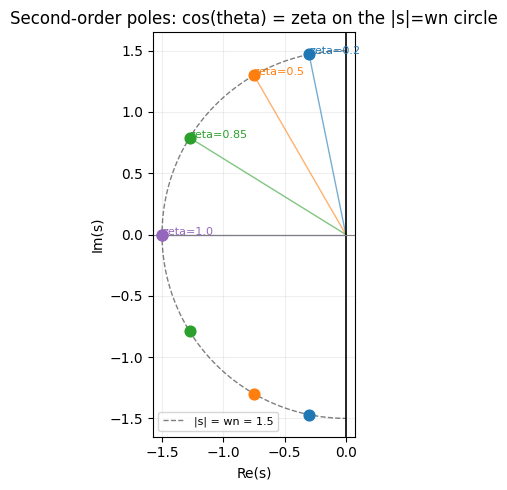

In [6]:
plotting.plot_damping_geometry(wn=1.5, zetas=(0.2, 0.5, 0.85, 1.0))
plt.tight_layout()

## 8. Failure Mode

- 分母 $as^2+bs+c$ の根が **右半面** にあると $y(t)$ が発散(不安定、06 章)。
- 入力 $g(t)$ が系の固有周波数と一致すると **共振**(虚軸極 + 同じ虚軸の入力)。
- 初期条件を入れ忘れると、過渡応答を取り違える。

## 8b. 共振のアニメーション (Applied)

軽い減衰の2次系をいろいろな駆動周波数 $\omega$ で揺らす。$\omega$ が固有振動数 $\omega_n$ に近づくと
応答振幅が跳ね上がる(**共振**)。各フレームのタイトルに $|H(i\omega)|$ を表示。

In [7]:
from IPython.display import HTML

anim = plotting.animate_resonance(omega_n=3.0, zeta=0.05)
html = anim.to_jshtml(fps=8)
plt.close("all")   # close the figure so the inline backend does not also show a static frame
HTML(html)

## 9. Application

RC/RLC 回路の過渡(07 章)、サスペンションの乗り心地、サーボの位置決め、いずれも本章のパイプラインそのもの。

## 10. Exercises

- **Basic**: $y'+2y=0,\ y(0)=3$ を $s$ 領域で解け。
- **Applied**: $y''+y=\sin t,\ y(0)=y'(0)=0$ の共振解を `Linv` で求め、振幅が $t$ に比例することを見よ。
- **Advanced**: 一般の $ay''+by'+cy=g$ の $Y(s)$ を導き、初期値項と強制項に分けて意味づけよ。

## 11. Advanced Notes

- **零状態応答 + 零入力応答**: $Y(s)=\underbrace{H(s)G(s)}_{\text{zero-state}} + \underbrace{\frac{\text{初期値項}}{as^2+bs+c}}_{\text{zero-input}}$。
  前者は伝達関数(05 章)、後者は初期条件由来。
- **共振の像**: 虚軸上の入力極が系の極と重なると重根化し、$t\sin\omega t$ が現れる。